In [1]:
import numpy as np
import pandas as pd
import mdtraj as md

import os 
import sys

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
CorrFuncLOC = 'E:/Users/Alan/Documents/Research/DiffusionTip4pDSoluteSize/'
CorrFuncLoc2 = 'D:/Research/LangevinDynamics_RotationalDiffusion/'
ENSEMBLES = ['NVE', 'NVT']
CouplingFrequency = ['CF0-2ps', 'CF2ps', 'CF20ps']
RUNS = ['Run{}'.format(n) for n in range(1,5,1)]
Proteins = ['GB3', 'Ubiquitin']
MINDX = pd.MultiIndex.from_product([Proteins, ENSEMBLES])
MINDX_NVT=pd.MultiIndex.from_product([Proteins, CouplingFrequency])
LocDF_NVE = pd.DataFrame(index=RUNS, columns=MINDX)
LocDF_NVE_R2 = LocDF_NVE.copy()
LocDF_NVE_R3 = LocDF_NVE.copy()
LocDF_NVT = pd.DataFrame(index=RUNS, columns=MINDX_NVT)
FileLocDict = {}

In [3]:
for items, values in LocDF_NVT.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVT.loc[indx, items] = '{}{}/PROD_NVT/{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)
        
for items, values in LocDF_NVE.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE.loc[indx, items] = '{}{}/PROD_{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'CF0-2ps')
('GB3', 'CF2ps')
('GB3', 'CF20ps')
('Ubiquitin', 'CF0-2ps')
('Ubiquitin', 'CF2ps')
('Ubiquitin', 'CF20ps')
('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [4]:
for items, values in LocDF_NVE_R2.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE_R2.loc[indx, items] = '{}{}/PROD_{}_Run2/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [5]:
for items, values in LocDF_NVE_R3.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE_R3.loc[indx, items] = '{}{}/PROD_{}_Run3/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [6]:
LocDF_NVE_R3['Ubiquitin'].iloc[0,0]

'D:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE_Run3/Run1'

In [7]:
LocDF_NVE.loc['Run1',('GB3','NVE')]

'D:/Research/LangevinDynamics_RotationalDiffusion/GB3/PROD_NVE/Run1'

In [8]:
GB3Top = md.load_prmtop('{}GB3/GB3_2Na_FF14SB.prmtop'.format(CorrFuncLOC))
GB3HInd = GB3Top.select('name CA and protein')
GB3Hatom_name = pd.Series(['{}'.format(GB3Top.atom(atmx)) for atmx in GB3HInd])
GB3atom_df = GB3Hatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
GB3atom_df['RESNAME'] = GB3atom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
GB3atom_df['RESID'] = GB3atom_df['RESNAME'].apply(lambda rr: int(rr[3:]))

In [9]:
UBQTop = md.load_prmtop('{}Analysis/Ubiquitin/PROD_noH20.UBQ_10mMNaCl_FF14SB.prmtop'.format(CorrFuncLOC))
UBQHInd = UBQTop.select('name CA and protein')
UBQHatom_name = pd.Series(['{}'.format(UBQTop.atom(atmx)) for atmx in UBQHInd])
UBQatom_df = UBQHatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
UBQatom_df['RESNAME'] = UBQatom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
UBQatom_df['RESID'] = UBQatom_df['RESNAME'].apply(lambda rr: int(rr[3:]))

In [10]:
UBQatom_df

,RESNAME,ATMNAME,RESID
0,MET1,CA,1
1,GLN2,CA,2
2,ILE3,CA,3
3,PHE4,CA,4
4,VAL5,CA,5
...,...,...,...
71,ARG72,CA,72
72,LEU73,CA,73
73,ARG74,CA,74
74,GLY75,CA,75


## Secondary Structure

In [11]:
AMBDSSPDICT = {0:'Coil',1:r'Parallel $\beta$-sheet',2:r'Anti-Parallel $\beta$-sheet', 3:'3-10 Helix' ,
                    4:r'$\alpha$-helix', 5:r'$\pi$-helix', 6:'Turn', 7:'Bend', 8:'PPII'}
AMBDSSP_DICT = {'Para':r'Parallel $\beta$-sheet', 'Anti':r'Anti-Parallel $\beta$-sheet', '3-10':'3-10 Helix',
                'Alpha':r'$\alpha$-helix', 'Pi':r'$\pi$-helix', 'Turn':'Turn', 'Bend':'Bend'}

In [ ]:
tseriesdf = pd.read_csv('{}/GB3_SS.dat'.format(LocDF_NVE.loc['Run1',('GB3','NVE')]),index_col=0,delim_whitespace=True)

In [12]:
def _read_DSSPSum(loc_df, fname, protein, ensemble, coupling=None):
    
    sim_mindx = pd.MultiIndex.from_product([loc_df.index.values, list(AMBDSSP_DICT.values())])
    
    indexdf = pd.read_csv('{}/{}'.format(loc_df[protein].iloc[0,0], fname),
                     index_col=0, delim_whitespace=True,usecols=[0])
    
    sim_DSSP_sumDF = pd.DataFrame(index=indexdf.index.values, columns=sim_mindx).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            sumdf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname),
                            index_col=0, delim_whitespace=True)
        elif ensemble == 'NVT':
            sumdf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, coupling)], fname),
                            index_col=0, delim_whitespace=True)
            
        sumdf = sumdf.rename(columns = AMBDSSP_DICT)
        indxcol = [(rind,cc) for cc in sumdf.columns]
        sim_DSSP_sumDF.loc[sumdf.index.values, indxcol] = sumdf.values
        
    return sim_DSSP_sumDF

In [35]:
gb3_sumdf_nve = _read_DSSPSum(LocDF_NVE, 'GB3_SS_Sum.out', 'GB3', 'NVE')
gb3_sumdf_nvt_cf02ps = _read_DSSPSum(LocDF_NVT, 'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF0-2ps')
gb3_sumdf_nvt_cf2ps  = _read_DSSPSum(LocDF_NVT,  'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF2ps')
gb3_sumdf_nvt_cf20ps = _read_DSSPSum(LocDF_NVT, 'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF20ps')

In [36]:
ubq_sumdf_nve = _read_DSSPSum(LocDF_NVE, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVE')
ubq_sumdf_nvt_cf02ps = _read_DSSPSum(LocDF_NVT, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF0-2ps')
ubq_sumdf_nvt_cf2ps  = _read_DSSPSum(LocDF_NVT,  'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF2ps')
ubq_sumdf_nvt_cf20ps = _read_DSSPSum(LocDF_NVT, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF20ps')

In [37]:
gb3_sumdf_nve_R2 = _read_DSSPSum(LocDF_NVE_R2, 'GB3_SS_Sum.out', 'GB3', 'NVE')
ubq_sumdf_nve_R2 = _read_DSSPSum(LocDF_NVE_R2, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVE')
ubq_sumdf_nve_R3 = _read_DSSPSum(LocDF_NVE_R3, 'UBQ_SS_Sum.out', 'Ubiquitin', 'NVE')

In [156]:
opt_gb3_dsspdf = gb3_sumdf_nve.copy()
opt_gb3_sumdf = gb3_sumdf_nve['Run3'].copy()
for nt, optttf in enumerate([gb3_sumdf_nve['Run3'], gb3_sumdf_nve['Run4'], gb3_sumdf_nve_R2['Run2'], gb3_sumdf_nve_R2['Run3']]):
    
    opt_gb3_dsspdf['Run{}'.format(nt+1)] = optttf
    opt_gb3_sumdf += optttf

opt_gb3_sumdf = ((opt_gb3_sumdf)/4)

In [157]:
opt_gb3_dsspdf.to_csv('{}{}/PROD_NVE/DSSP_OptSim.csv'.format(CorrFuncLoc2,'GB3'))
opt_gb3_sumdf.to_csv('{}{}/PROD_NVE/DSSP_SUM_OptSim.csv'.format(CorrFuncLoc2,'GB3'))

In [154]:
opt_ubq_dsspdf = ubq_sumdf_nve.copy()
opt_ubq_sumdf = ubq_sumdf_nve['Run1'].copy()
for nt, optttf in enumerate([ubq_sumdf_nve['Run1'], ubq_sumdf_nve['Run3'],
                             ubq_sumdf_nve_R2['Run1'], ubq_sumdf_nve_R3['Run3']]):
    
    opt_ubq_dsspdf['Run{}'.format(nt+1)] = optttf 
    opt_ubq_sumdf += optttf

opt_ubq_sumdf = ((opt_ubq_sumdf)/4)

In [155]:
opt_ubq_dsspdf.to_csv('{}{}/PROD_NVE/DSSP_OptSim.csv'.format(CorrFuncLoc2,'Ubiquitin'))
opt_ubq_sumdf.to_csv('{}{}/PROD_NVE/DSSP_SUM_OptSim.csv'.format(CorrFuncLoc2,'Ubiquitin'))

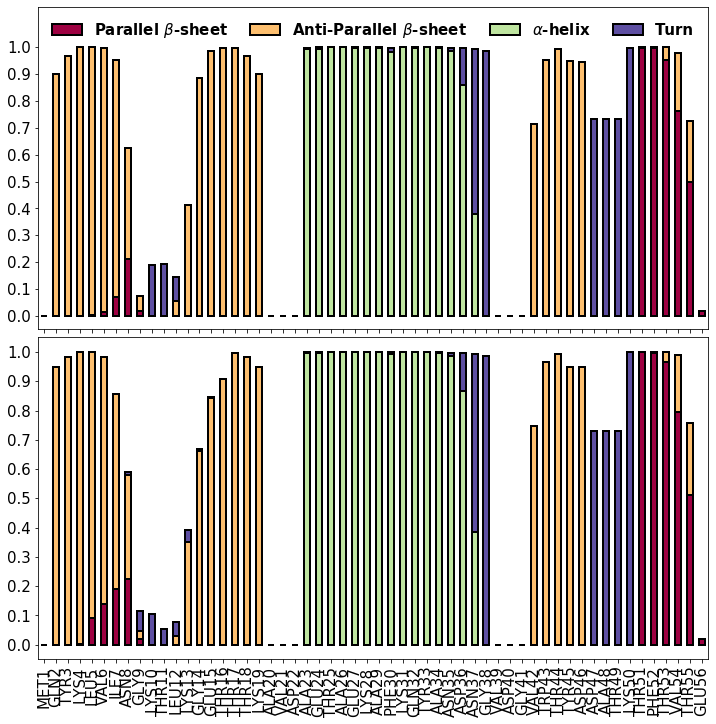

In [40]:
fig_gb3_dssp, axgb3dssp = plt.subplots(2,1, figsize=(12,12), sharex=True)
fig_gb3_dssp.subplots_adjust(hspace=0.025)

axgb3dssp_nve = axgb3dssp[0]
axgb3dssp_nve.set_xlim(0.0,55.0)
axgb3dssp_nve.set_ylim(-0.05,1.15)
opt_gb3_sumdf.plot.bar(ax=axgb3dssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axgb3dssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axgb3dssp_nve.tick_params(labelsize=15)
axgb3dssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))

axgb3dssp_nvt = axgb3dssp[1]
gb3_sumdf_nvt_cf2ps_avg = gb3_sumdf_nvt_cf2ps.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
axgb3dssp_nvt.set_xlim(0.0,55.0)
axgb3dssp_nvt.set_ylim(-0.05,1.05)
gb3_sumdf_nvt_cf2ps_avg.plot.bar(ax=axgb3dssp_nvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
axgb3dssp_nvt.tick_params(labelsize=15)
axgb3dssp_nvt.set_yticks(np.arange(0.0, 1.1, 0.10))
axgb3dssp_nvt.set_xticklabels(GB3atom_df['RESNAME'].values, rotation=90)

fig_gb3_dssp.savefig('{}/GB3/Analysis/CompareSecondaryStructure_NVE_NVTCf2ps.png'.format(CorrFuncLoc2),
                     dpi=600, bbox_inches='tight')

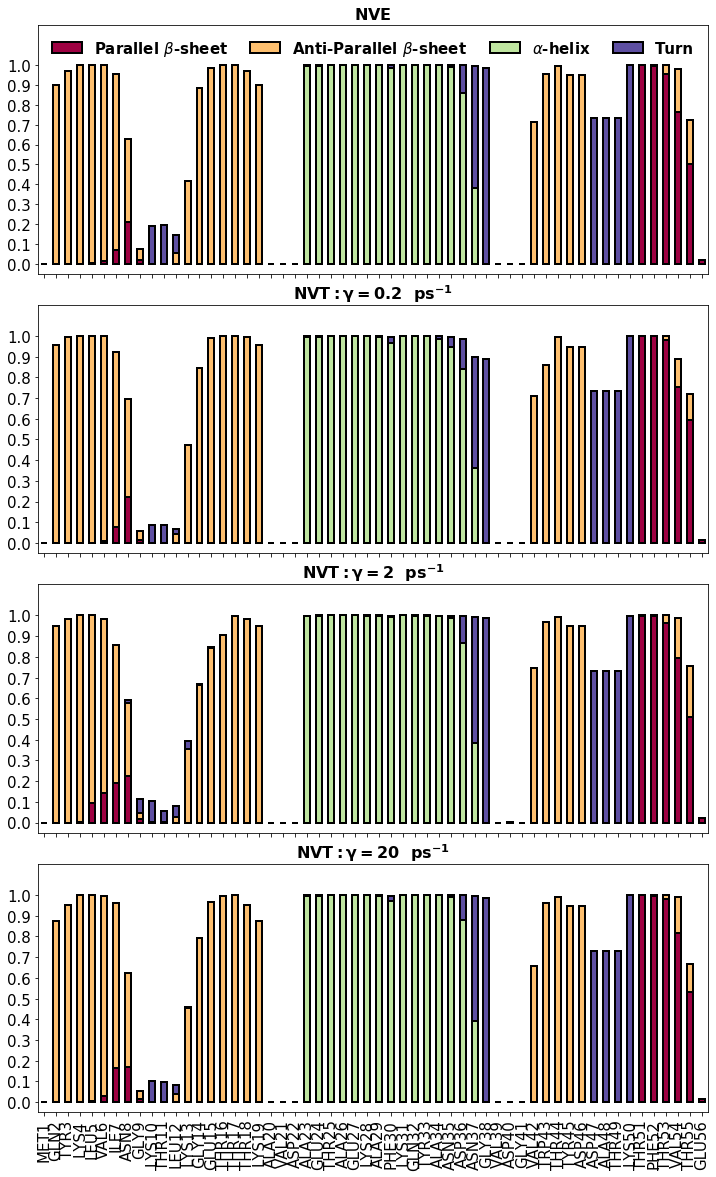

In [41]:
fig_gb3_dssp, axgb3dssp = plt.subplots(4,1, figsize=(12,20), sharex=True, num=20193)
fig_gb3_dssp.subplots_adjust(hspace=0.125)

axgb3dssp_nve = axgb3dssp[0]
axgb3dssp_nve.set_xlim(0.0,55.0)
axgb3dssp_nve.set_ylim(-0.05,1.20)
opt_gb3_sumdf.plot.bar(ax=axgb3dssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axgb3dssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axgb3dssp_nve.tick_params(labelsize=15)
axgb3dssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))
axgb3dssp_nve.set_title(r'$\mathbf{NVE}$', fontsize=16)
nvt_labels = [r'$\mathbf{ NVT : \gamma = 0.2 \ \ ps^{-1}}$', 
              r'$\mathbf{ NVT : \gamma = 2 \ \ ps^{-1}}$',
              r'$\mathbf{ NVT : \gamma = 20 \ \ ps^{-1}}$']

for axnvt, data, text_title in zip(axgb3dssp[1:],[gb3_sumdf_nvt_cf02ps, gb3_sumdf_nvt_cf2ps, gb3_sumdf_nvt_cf20ps], nvt_labels):
    nvt_avg = data.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
    axnvt.set_xlim(0.0,55.0)
    axnvt.set_ylim(-0.05,1.15)
    nvt_avg.plot.bar(ax=axnvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
    axnvt.tick_params(labelsize=15)
    axnvt.set_yticks(np.arange(0.0, 1.1, 0.10))
    axnvt.set_title(text_title, fontsize=16)
    
axgb3dssp[3].set_xticklabels(GB3atom_df['RESNAME'].values, rotation=90)

fig_gb3_dssp.savefig('{}/GB3/Analysis/CompareSecondaryStructure_NVE_AllNVT.png'.format(CorrFuncLoc2),
                     dpi=600, bbox_inches='tight')

[Text(0, 0, 'MET1'),
 Text(0, 0, 'GLN2'),
 Text(0, 0, 'ILE3'),
 Text(0, 0, 'PHE4'),
 Text(0, 0, 'VAL5'),
 Text(0, 0, 'LYS6'),
 Text(0, 0, 'THR7'),
 Text(0, 0, 'LEU8'),
 Text(0, 0, 'THR9'),
 Text(0, 0, 'GLY10'),
 Text(0, 0, 'LYS11'),
 Text(0, 0, 'THR12'),
 Text(0, 0, 'ILE13'),
 Text(0, 0, 'THR14'),
 Text(0, 0, 'LEU15'),
 Text(0, 0, 'GLU16'),
 Text(0, 0, 'VAL17'),
 Text(0, 0, 'GLU18'),
 Text(0, 0, 'PRO19'),
 Text(0, 0, 'SER20'),
 Text(0, 0, 'ASP21'),
 Text(0, 0, 'THR22'),
 Text(0, 0, 'ILE23'),
 Text(0, 0, 'GLU24'),
 Text(0, 0, 'ASN25'),
 Text(0, 0, 'VAL26'),
 Text(0, 0, 'LYS27'),
 Text(0, 0, 'ALA28'),
 Text(0, 0, 'LYS29'),
 Text(0, 0, 'ILE30'),
 Text(0, 0, 'GLN31'),
 Text(0, 0, 'ASP32'),
 Text(0, 0, 'LYS33'),
 Text(0, 0, 'GLU34'),
 Text(0, 0, 'GLY35'),
 Text(0, 0, 'ILE36'),
 Text(0, 0, 'PRO37'),
 Text(0, 0, 'PRO38'),
 Text(0, 0, 'ASP39'),
 Text(0, 0, 'GLN40'),
 Text(0, 0, 'GLN41'),
 Text(0, 0, 'ARG42'),
 Text(0, 0, 'LEU43'),
 Text(0, 0, 'ILE44'),
 Text(0, 0, 'PHE45'),
 Text(0, 0, 'ALA46'

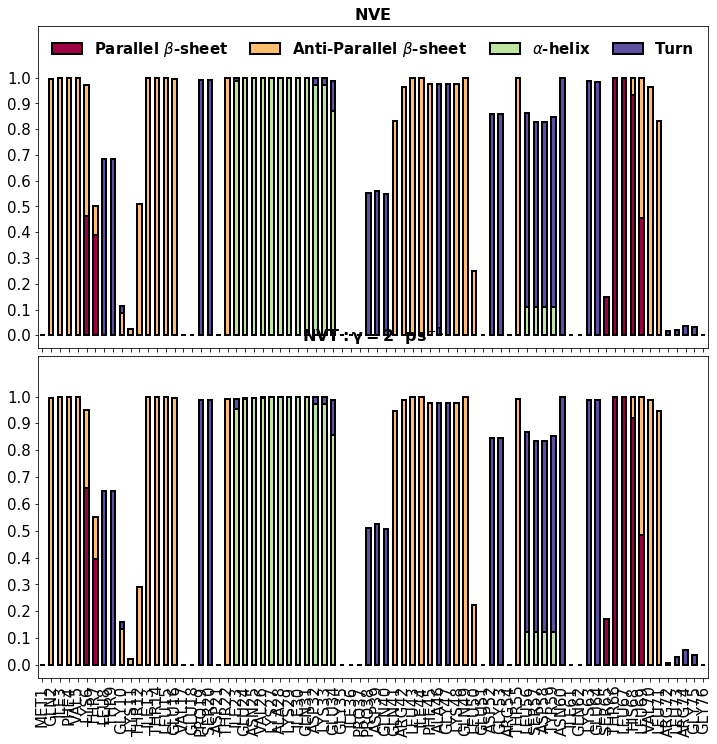

In [143]:
fig_ubq_dssp2, axubqdssp2 = plt.subplots(2,1, figsize=(12,12), sharex=True, num=20196)
fig_ubq_dssp2.subplots_adjust(hspace=0.025)

axubqdssp_nve = axubqdssp2[0]
axubqdssp_nve.set_xlim(0.0,55.0)
axubqdssp_nve.set_ylim(-0.05,1.20)
opt_ubq_sumdf.plot.bar(ax=axubqdssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axubqdssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axubqdssp_nve.tick_params(labelsize=15)
axubqdssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))
axubqdssp_nve.set_title(r'$\mathbf{NVE}$', fontsize=16)
nvt_labels = [r'$\mathbf{ NVT : \gamma = 0.2 \ \ ps^{-1}}$', 
              r'$\mathbf{ NVT : \gamma = 2 \ \ ps^{-1}}$',
              r'$\mathbf{ NVT : \gamma = 20 \ \ ps^{-1}}$']

axnvt = axubqdssp2[1]
data = ubq_sumdf_nvt_cf2ps
nvt_avg = data.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
axnvt.set_xlim(0.0,55.0)
axnvt.set_ylim(-0.05,1.15)
nvt_avg.plot.bar(ax=axnvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
axnvt.tick_params(labelsize=15)
axnvt.set_yticks(np.arange(0.0, 1.1, 0.10))
axnvt.set_title(nvt_labels[1], fontsize=16, pad=14)
    
axnvt.set_xticklabels(UBQatom_df['RESNAME'].values, rotation=90)

#fig_ubq_dssp2.savefig('{}/Ubiquitin/Analysis/CompareSecondaryStructure_NVE_AllNVT.png'.format(CorrFuncLoc2),
#                     dpi=600, bbox_inches='tight')

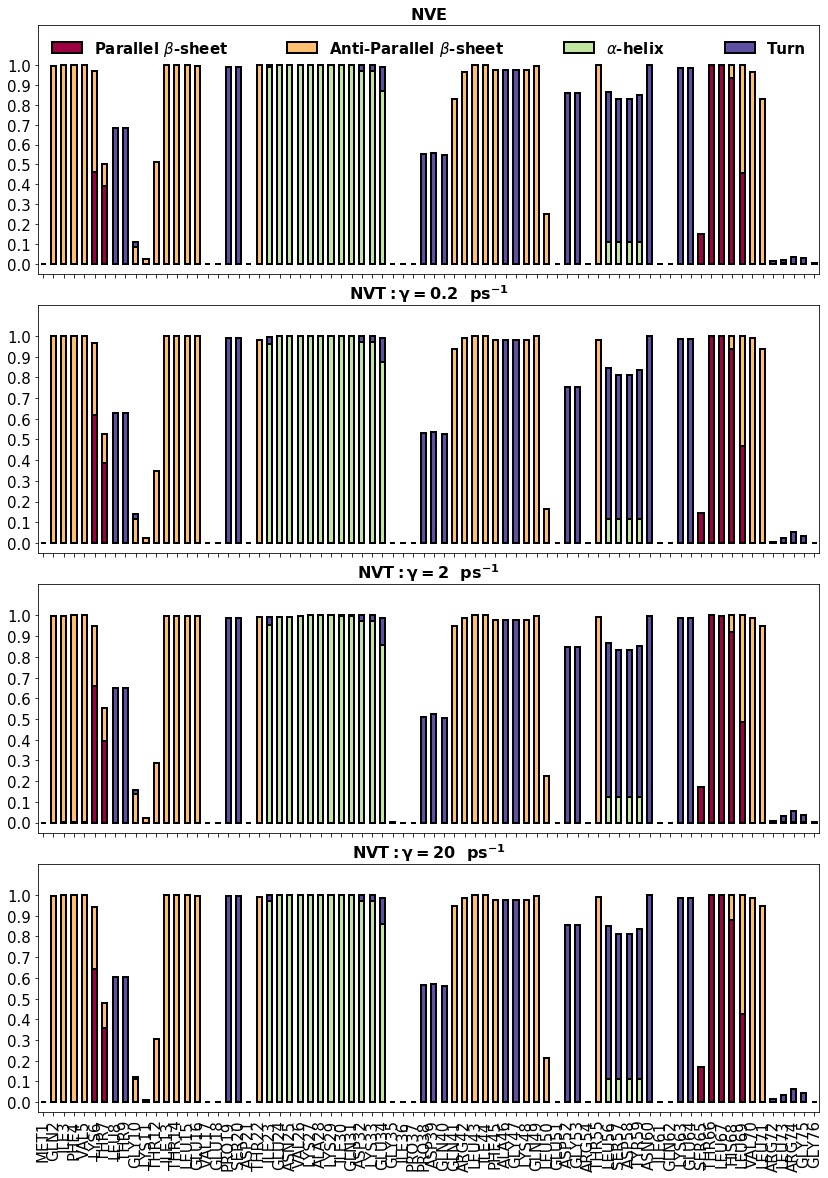

In [48]:
fig_ubq_dssp, axubqdssp = plt.subplots(4,1, figsize=(14,20), sharex=True, num=20195)
fig_ubq_dssp.subplots_adjust(hspace=0.125)

axubqdssp_nve = axubqdssp[0]
axubqdssp_nve.set_xlim(0.0,55.0)
axubqdssp_nve.set_ylim(-0.05,1.20)
opt_ubq_sumdf.plot.bar(ax=axubqdssp_nve, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k')
axubqdssp_nve.legend(ncol=4, mode='expand', frameon=False, prop={'size':15, 'weight':'bold'})
axubqdssp_nve.tick_params(labelsize=15)
axubqdssp_nve.set_yticks(np.arange(0.0, 1.1, 0.10))
axubqdssp_nve.set_title(r'$\mathbf{NVE}$', fontsize=16)
nvt_labels = [r'$\mathbf{ NVT : \gamma = 0.2 \ \ ps^{-1}}$', 
              r'$\mathbf{ NVT : \gamma = 2 \ \ ps^{-1}}$',
              r'$\mathbf{ NVT : \gamma = 20 \ \ ps^{-1}}$']

for axnvt, data, text_title in zip(axubqdssp[1:],[ubq_sumdf_nvt_cf02ps, ubq_sumdf_nvt_cf2ps, ubq_sumdf_nvt_cf20ps], nvt_labels):
    nvt_avg = data.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])
    axnvt.set_xlim(0.0,55.0)
    axnvt.set_ylim(-0.05,1.15)
    nvt_avg.plot.bar(ax=axnvt, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
    axnvt.tick_params(labelsize=15)
    axnvt.set_yticks(np.arange(0.0, 1.1, 0.10))
    axnvt.set_title(text_title, fontsize=16)
    
axubqdssp[3].set_xticklabels(UBQatom_df['RESNAME'].values, rotation=90)

fig_ubq_dssp.savefig('{}/Ubiquitin/Analysis/CompareSecondaryStructure_NVE_AllNVT.png'.format(CorrFuncLoc2),
                     dpi=600, bbox_inches='tight')

(-1, 76)

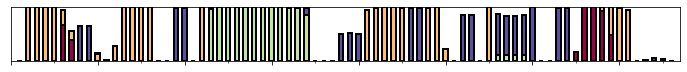

In [71]:
figSSSlim, axnvtslim = plt.subplots(1, 1, figsize=(12,1), num=33321)
data = ubq_sumdf_nvt_cf2ps
nvt_avg = data.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Bend'])

axnvtslim.set_ylim(0.0,1.0)
nvt_avg.plot.bar(ax=axnvtslim, cmap='Spectral', linewidth=2, stacked=True, edgecolor='k', legend=False)
axnvtslim.tick_params(labelsize=15)
axnvtslim.set_yticks([])
axnvtslim.set_yticklabels([])
axnvtslim.set_xticks(np.arange(-1,76,10))
axnvtslim.set_xticks(np.arange(-1,76,5), minor=True)
#axnvtslim.set_xticklabels(np.arange(0,75,10))
axnvtslim.set_xticklabels([])
axnvtslim.set_xlim(-1,76)


In [70]:
data.shape

(76, 28)

In [ ]:
ubq_sumdf_nve.mean(axis=1,level=1).drop(columns=['3-10 Helix',r'$\pi$-helix','Turn','Bend']).plot(cmap='Dark2')

In [ ]:


gb3_sumdf_nve.mean(axis=1,level=1).drop(columns=[r'$\pi$-helix','Turn','Bend']).plot()
gb3_sumdf_nvt_cf2ps.mean(axis=1,level=1).drop(columns=[r'$\pi$-helix','Turn','Bend']).plot(ax=plt.gca())

In [ ]:
testdf = pd.read_csv('{}/GB3_SS_sum.out'.format(LocDF_NVE.loc[RIND,('GB3','NVE')]),
                     index_col=0, delim_whitespace=True,usecols=[0])

In [ ]:
RMINDX = pd.MultiIndex.from_product([LocDF_NVE.index.values, list(AMBDSSP_DICT.values())])
gb3_sumdf_nve = pd.DataFrame(index = np.arange(1,57,1), columns = RMINDX).fillna(0.0)

In [ ]:
RMINDX = pd.MultiIndex.from_product([LocDF_NVE.index.values, list(AMBDSSP_DICT.values())])
for RIND in gb3_sumdf_nve.columns.levels[0]:
    sumdf = pd.read_csv('{}/GB3_SS_sum.out'.format(LocDF_NVE.loc[RIND,('GB3','NVE')]), index_col=0, delim_whitespace=True)
    sumdf = sumdf.rename(columns = AMBDSSP_DICT)
    indxcol = [(RIND,cc) for cc in sumdf.columns]
    gb3_sumdf_nve.loc[sumdf.index.values, indxcol] = sumdf.values

In [ ]:
RMINDX = pd.MultiIndex.from_product([LocDF_NVE.index.values, list(AMBDSSP_DICT.values())])
for RIND in gb3_sumdf_nve.columns.levels[0]:
    sumdf = pd.read_csv('{}/GB3_SS_sum.out'.format(LocDF_NVE.loc[RIND,('GB3','NVE')]), index_col=0, delim_whitespace=True)
    sumdf = sumdf.rename(columns = AMBDSSP_DICT)
    indxcol = [(RIND,cc) for cc in sumdf.columns]
    gb3_sumdf_nve.loc[sumdf.index.values, indxcol] = sumdf.values

In [ ]:
gb3_sumdf_nve.mean(axis=1,level=1).plot()

In [ ]:
sumdf.plot()

## RMSD

In [16]:
def _read_RMSD(loc_df, fname, protein, ensemble, coupling=None, nsnaps=1000000):

    
    sim_RMSDDF = pd.DataFrame(index=np.arange(1, nsnaps+1, 1), columns=loc_df.index.values).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            rmsddf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname),
                            index_col=0, delim_whitespace=True)
            
        elif ensemble == 'NVT':
            rmsddf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, coupling)], fname),
                            index_col=0, delim_whitespace=True)
            
        sim_RMSDDF.loc[:,rind] = rmsddf
    
    sim_RMSDDF.index = sim_RMSDDF.index.values*0.0005
        
    return sim_RMSDDF

In [ ]:
RMSDDF_GB3_NVE = _read_RMSD(LocDF_NVE, 'Backbone_RMSD.dat', 'GB3', 'NVE', coupling=None, nsnaps=1000000 )
RMSDDF_GB3_NVT_Cf02ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'GB3', 'NVT', coupling='CF0-2ps', nsnaps=2000000 )
RMSDDF_GB3_NVT_Cf2ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'GB3', 'NVT', coupling='CF2ps', nsnaps=2000000 )
RMSDDF_GB3_NVT_Cf20ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'GB3', 'NVT', coupling='CF20ps', nsnaps=2000000 )

In [ ]:
RMSDDF_UBQ_NVE = _read_RMSD(LocDF_NVE, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000 )
RMSDDF_UBQ_NVT_Cf02ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVT', coupling='CF0-2ps', nsnaps=2000000 )
RMSDDF_UBQ_NVT_Cf2ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVT', coupling='CF2ps', nsnaps=2000000 )
RMSDDF_UBQ_NVT_Cf20ps = _read_RMSD(LocDF_NVT, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVT', coupling='CF20ps', nsnaps=2000000 )

In [17]:
RMSDDF_GB3_NVE_R2 = _read_RMSD(LocDF_NVE_R2, 'Backbone_RMSD.dat', 'GB3', 'NVE', coupling=None, nsnaps=1000000 )
RMSDDF_UBQ_NVE_R2 = _read_RMSD(LocDF_NVE_R2, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000 )
RMSDDF_UBQ_NVE_R3 = _read_RMSD(LocDF_NVE_R3, 'Backbone_RMSD.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000 )

In [19]:
RMSDDF_NVE = pd.DataFrame(index=np.arange(1,1000001,1), columns=RUNS).fillna(0.0)
for R in RUNS:
    rmsddf = pd.read_csv('{}/Backbone_RMSD.dat'.format(LocDF_NVE.loc[R, ('GB3','NVE')]),
                         index_col=0, delim_whitespace=True)
    RMSDDF_NVE.loc[:, R] = rmsddf.loc[RMSDDF_NVE.index.values,:]
    

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\numpy\lib\arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


In [20]:
RMSDDF_NVT = pd.DataFrame(index=np.arange(1,2000001,1), columns=RUNS).fillna(0.0)
for R in RUNS:
    rmsddf = pd.read_csv('{}/Backbone_RMSD.dat'.format(LocDF_NVT.loc[R, ('GB3','CF0-2ps')]),
                         index_col=0, delim_whitespace=True)
    RMSDDF_NVT.loc[:, R] = rmsddf

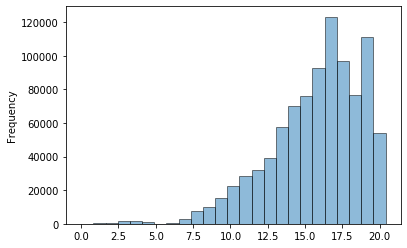

In [159]:
RMSDDF_UBQ_NVE_R2['Run3'].plot.hist(bins=25, alpha=0.5, edgecolor='k')

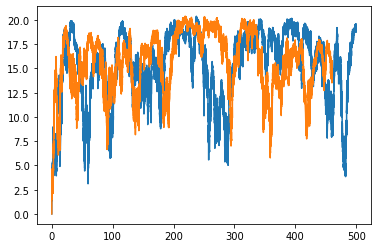

In [25]:
RMSDDF_UBQ_NVE_R3['Run3'].plot()
RMSDDF_UBQ_NVE_R2['Run3'].plot()

In [ ]:
def BCF(res_qn0, res_an, res_bn, n, i):
    return 1 + (res_qn0 - 1)/(1 + res_an*abs(n-i) + res_bn*np.square(abs(n-i)) )

In [ ]:
seq = 'MRDRSPRSPRRERSP'
seq2var_dict = {''}

## SASA Calculation

In [89]:
import tarfile
import codecs
import io

In [108]:
sasas_tar = tarfile.open('{}{}/GB3_SASA_DataAll.tar.gz'.format(CorrFuncLoc2, 'GB3'), 'r:gz', encoding='utf-8')



In [109]:
res1_tar = sasas_tar.extractfile('./PROD_NVE_Run2/Analysis/Run3/Surface/Surface_Res11.dat').read()

In [96]:
res1_tar = sasas_tar.getmember('./PROD_NVE_Run2/Analysis/Run3/Surface/Surface_Res11.dat')


In [111]:
buffer = io.BytesIO(res1_tar)

In [117]:
pd.read_csv(io.BytesIO(res1_tar), encoding='utf8', delim_whitespace=True)

,#Frame,R11
0,1,134.7659
1,2,133.1622
2,3,129.2629
3,4,123.2151
4,5,124.9123
...,...,...
999995,999996,80.1547
999996,999997,85.3235
999997,999998,77.1244
999998,999999,75.9010


In [92]:
pd.read_csv(io.BytesIO(res1_tar), encoding='utf8', delim_whitespace=True, index_col=0)

,70139.025363..,1390..,70137.471763..,1391..,70139.968863.,71392..,70138.671663.,71393..,70140.809763..,1394..,...,70.84272,76.427763.699996..,70.84273,84.969663.699997..,70.84274,74.750863.699998..,70.84275,77.138963.699999..,70.84276,75.8840
9.666063...1389..,,,,,,,,,,,,,,,,,,,,,
0,700000..,70,76.974663.700001..,70,74.017363.700002..,70,77.302763.700003..,70,78.260763.700004..,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,700031..,70,74.408863.700032..,70,73.463863.700033..,70,72.225363.700034..,70,83.063863.700035..,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,700057..,70,83.847463.700058..,70,84.501463.700059..,70,81.033263.700060..,70,79.368763.700061..,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
def _read_SurfaceCalculation(protein, ensemble, atom_df, coupling='CF2ps'):
    
    
    runsmindx = pd.MultiIndex.from_product([RUNS, atom_df.RESID])
    
    surfalldf = pd.DataFrame(index=np.arange(1, 1000001, 1), columns=runsmindx).fillna(0.0)
    
    ## if you are using the gunzipped tarball method to save space start here
    ## else: comment out the tarball statements and proceed
    
    for rind in RUNS:
        print(rind)
        for resid in atom_df.RESID:
            #print(resid)
            if ensemble == 'NVE':
                fileloc = '{}{}/PROD_NVE/Analysis/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, protein, rind, resid)
                surfdf = pd.read_csv(fileloc, delim_whitespace=True, index_col=0 )
        
            elif ensemble == 'NVE_Run2':
                fileloc = '{}{}/PROD_NVE_Run2/Analysis/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, protein, rind, resid)
                surfdf = pd.read_csv(fileloc, delim_whitespace=True,  index_col=0)
            
            elif ensemble == 'NVT':
                fileloc = '{}{}/PROD_NVT/{}/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, protein, coupling, rind, resid)
                surfdf = pd.read_csv(fileloc, delim_whitespace=True,  index_col=0 )
            
            surfalldf[(rind,resid)] = surfdf.loc[surfalldf.index.values, 'R{}'.format(resid)]
    
    return surfalldf

In [128]:
def _read_SurfaceCalculation_tarball(protein, ensemble, atom_df, coupling='Coupling2ps'):
    
    
    runsmindx = pd.MultiIndex.from_product([RUNS, atom_df.RESID])
    
    surfalldf = pd.DataFrame(index=np.arange(1, 1000001, 1), columns=runsmindx).fillna(0.0)
    
    ## if you are using the gunzipped tarball method to save space start here
    ## else: comment out the tarball statements and proceed
    tarfname = '{}{}/{}_SASA_DataAll.tar.gz'.format(CorrFuncLoc2, protein, protein)
    with tarfile.open(tarfname, 'r:gz',encoding='utf-8') as sasatar:
        
        for rind in RUNS:
            print(rind)
            for resid in atom_df.RESID:
                #print(resid)
                if ensemble == 'NVE':
                    tarmemberloc = './PROD_NVE/Analysis/{}/Surface/Surface_Res{}.dat'.format(rind, resid)
                    sasa_extract = sasatar.extractfile(tarmemberloc).read()
                    surfdf = pd.read_csv(io.BytesIO(sasa_extract), delim_whitespace=True, encoding='utf8')
        
                elif ensemble == 'NVE_Run2':
                    tarmemberloc = './PROD_NVE_Run2/Analysis/{}/Surface/Surface_Res{}.dat'.format(rind, resid)
                    sasa_extract = sasatar.extractfile(tarmemberloc).read()
                    surfdf = pd.read_csv(io.BytesIO(sasa_extract), delim_whitespace=True, encoding='utf8')
            
                elif ensemble == 'NVT':
                    tarmemberloc = './PROD_NVT/{}/Analysis/{}/Surface/Surface_Res{}.dat'.format(coupling, rind, resid)
                    sasa_extract = sasatar.extractfile(tarmemberloc).read()
                    surfdf = pd.read_csv(io.BytesIO(sasa_extract), delim_whitespace=True, encoding='utf8')
            
                surfalldf[(rind,resid)] = surfdf.set_index('#Frame').loc[surfalldf.index.values, 'R{}'.format(resid)]
    
    return surfalldf

In [124]:
SURFAlldf_NVE = _read_SurfaceCalculation_tarball('GB3', 'NVE', GB3atom_df, coupling='CF0-2ps')
#SURFAlldf_NVER2 = _read_SurfaceCalculation_tarball('GB3', 'NVE_Run2', GB3atom_df, coupling='CF0-2ps')

Run1
Run2
Run3
Run4


In [129]:
GB3_SURFAlldf_NVT_Cf2ps = _read_SurfaceCalculation_tarball('GB3', 'NVT', GB3atom_df, coupling='Coupling2ps')

Run1
Run2
Run3
Run4


In [139]:
GB3_SURFAlldf_NVT_Cf2ps.mean(axis=0).unstack().mean().to_csv('{}{}/PROD_NVT/CF2ps/AvgSASA_Res.csv'.format(CorrFuncLoc2,'GB3'))

In [142]:
UBQ_SURFAlldf_Cf2ps = _read_SurfaceCalculation_tarball('Ubiquitin', 'NVT', UBQatom_df, coupling='Coupling2ps')

Run1
Run2
Run3
Run4


In [144]:
UBQ_SURFAlldf_Cf2ps.mean(axis=0).unstack().mean().to_csv('{}{}/PROD_NVT/CF2ps/AvgSASA_Res.csv'.format(CorrFuncLoc2,'Ubiquitin'))

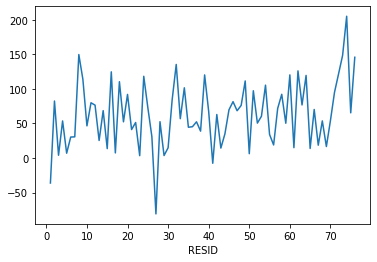

In [147]:
UBQ_SURFAlldf_Cf2ps.mean(axis=0).unstack().mean().plot()

In [ ]:
SURFAlldf_NVE = _read_SurfaceCalculation('Ubiquitin', 'NVE', UBQatom_df, coupling='CF0-2ps')

In [ ]:
SURFAlldf_NVER2 = _read_SurfaceCalculation('Ubiquitin', 'NVE_Run3', UBQatom_df, coupling='CF0-2ps')
SURFAlldf_NVER3 = _read_SurfaceCalculation('Ubiquitin', 'NVE_Run3', UBQatom_df, coupling='CF0-2ps')

In [ ]:
SURFAlldf_Cf02ps = _read_SurfaceCalculation('Ubiquitin', 'NVT', UBQatom_df, coupling='CF0-2ps')
SURFAlldf_Cf20ps = _read_SurfaceCalculation('Ubiquitin', 'NVT', UBQatom_df, coupling='CF20ps')

In [ ]:
SURFAlldf_Cf2ps = _read_SurfaceCalculation('GB3', 'NVT', UBQatom_df, coupling='CF2ps')


In [ ]:
SURFAlldf_Cf2ps_4plot = SURFAlldf_Cf2ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
sns.lineplot(x='RESID', y='SASA', data=SURFAlldf_Cf2ps_4plot)

In [ ]:
surfdf = pd.read_csv('D:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/Analysis/Run1/Surface/Surface_Res2.dat',
            delim_whitespace=True)

In [ ]:
SURFAlldf_4Plot = SURFAlldf.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
sns.lineplot(x='RESID', y='SASA', data=SURFAlldf_4Plot)

In [ ]:
sns.heatmap(SURFAlldf.mean(axis=0).unstack().mean().reset_index())

In [ ]:
def _plot_SASAHeatmap(plot_data, atom_df, fnum=32131):
    
    fig_SASA = plt.figure(91842, figsize=(16,2.0))
    cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
    axSASA = fig_SASA.add_subplot(111)
    
    sasa_mean = plot_data.mean(axis=0).unstack().mean().values.reshape(1,-1)
    sasa_ref = sasa_mean/sasa_mean.max()
    cmap = axSASA.imshow(sasa_ref, cmap='viridis', aspect='auto')
    
    fig_SASA.colorbar(cmap, cax=cmapax,orientation='horizontal')
    axSASA.set_yticks([])
    axSASA.set_xticks(np.arange(0, atom_df.shape[0]+1,1))
    axSASA.set_xticklabels(atom_df.RESNAME, rotation=90)
    cmapax.xaxis.tick_top()
    cmapax.tick_params(labelsize=15)
    axSASA.tick_params(labelsize=14)
    cmapax.xaxis.set_label_position('top')
    cmapax.set_xlabel(r'$\mathbf{SASA/max(SASA) \ \ (\AA^{2})}$', fontsize=15)
    
    for j, val in enumerate(sasa_ref.flatten()):
        #print(j,val)
        text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center", color="w", rotation=90, fontweight='bold')
    
    return fig_SASA

In [ ]:
def _plot_SASAHeatmap(plot_data, atom_df, fnum=32131):
    
    fig_SASA = plt.figure(91842, figsize=(16,2.0))
    cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
    axSASA = fig_SASA.add_subplot(111)
    
    sasa_mean = plot_data.mean(axis=0).unstack().mean().values.reshape(1,-1)
    sasa_ref = sasa_mean/sasa_mean.max()
    cmap = axSASA.imshow(sasa_ref, cmap='viridis', aspect='auto')
    
    fig_SASA.colorbar(cmap, cax=cmapax,orientation='horizontal')
    axSASA.set_yticks([])
    axSASA.set_xticks(np.arange(0, atom_df.shape[0]+1,1))
    axSASA.set_xticklabels(atom_df.RESNAME, rotation=90)
    cmapax.xaxis.tick_top()
    cmapax.tick_params(labelsize=15)
    axSASA.tick_params(labelsize=14)
    cmapax.xaxis.set_label_position('top')
    cmapax.set_xlabel(r'$\mathbf{SASA/max(SASA) \ \ (\AA^{2})}$', fontsize=15)
    
    for j, val in enumerate(sasa_ref.flatten()):
        #print(j,val)
        text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center", color="w", rotation=90, fontweight='bold')
    
    return fig_SASA

In [26]:
## Read SASA PDBs:
SASAList = ['Defensin/2LZI', 'TRPCage/1L2Y', 'SHK/1ROO', 'GB3/1p7e',
            'BPTI/1pit', 'Ubiquitin/1UBQ', 'RibonucleaseT1/1YGW', 'HEWL/1E8L']
reference_SASA_dict = {'ALA':106,'ARG':248,'ASN':157,'ASP':163,
                      'CYS':135,'GLN':198,'GLU':194,'GLY':84,
                      'HIS':184,'ILE':169,'LEU':164,'LYS':205,
                      'MET':188,'PHE':197,'PRO':136,'SER':130,
                      'THR':142,'TRP':227, 'TYR':222,'VAL':142}

In [ ]:
SURFAlldf_NVE_4Plot = SURFAlldf_NVE.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_NVER2_4Plot = SURFAlldf_NVER2.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_Cf02ps_4Plot = SURFAlldf_Cf02ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_Cf2ps_4Plot = SURFAlldf_Cf2ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})
SURFAlldf_Cf02ps_4Plot = SURFAlldf_Cf20ps.mean().reset_index().rename(columns={'level_0':'Runs',0:'SASA'})

In [ ]:
SURFAlldf_NVER2

In [ ]:
fig_SASA_NVER2 = _plot_SASAHeatmap(SURFAlldf_NVER2, UBQatom_df)
fig_SASA_NVER2.savefig('{}Ubiquitin/PROD_NVE_Run2/Analysis/SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

In [ ]:
fig_SASA_NVE = _plot_SASAHeatmap(SURFAlldf_NVE, UBQatom_df)
fig_SASA_NVE.savefig('{}Ubiquitin/PROD_NVE/Analysis/SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

In [ ]:
fig_SASA_NVT_Cf02ps = _plot_SASAHeatmap(SURFAlldf_Cf02ps, UBQatom_df)
fig_SASA_NVT_Cf02ps.savefig('{}Ubiquitin/Analysis/NVT_CF02ps_SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

In [ ]:
fig_SASA_NVT_Cf2ps = _plot_SASAHeatmap(SURFAlldf_Cf2ps, UBQatom_df)
fig_SASA_NVT_Cf2ps.savefig('{}Ubiquitin/Analysis/NVT_CF2ps_SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

In [ ]:
fig_SASA_NVT_Cf20ps = _plot_SASAHeatmap(SURFAlldf_Cf20ps, UBQatom_df)
fig_SASA_NVT_Cf20ps.savefig('{}Ubiquitin/Analysis/NVT_CF20ps_SASA_Heatmap_Normalized.png'.format(CorrFuncLoc2),
                       dpi=600, bbox_inches='tight')

In [ ]:
fig_SASA_NVT_Cf02ps = _plot_SASAHeatmap(SURFAlldf_Cf02ps, UBQatom_df)

In [ ]:
SURFAlldf.mean(axis=0).unstack().columns

In [ ]:

RunsMINDX = pd.MultiIndex.from_product([RUNS, UBQatom_df.RESID])
SURFAlldf = pd.DataFrame(index=np.arange(1, 1000001, 1), columns=RunsMINDX)

for R in RUNS:
    
    for resid in UBQatom_df.RESID:
        fileloc = '{}Ubiquitin/PROD_NVE_Run2/Analysis/{}/Surface/Surface_Res{}.dat'.format(CorrFuncLoc2, R, resid)
        surfdf = pd.read_csv(fileloc, delim_whitespace=True, index_col=0 )
        SURFAlldf[(R,resid)] = surfdf.loc[SURFAlldf.index, 'R{}'.format(resid)]

In [ ]:
SURFAlldf

106, 248, 157, 163, 135, 198, 194, 84, 184,169, 164, 205, 188, 197, 136, 130, 142, 227, 222, and 142 Å2 for 
Ala, Arg, Asn, Asp, Cys, Gln, Glu, Gly, His, Ile, Leu, Lys, Met, Phe, Pro, Ser, Thr, Trp, Tyr, and Val

In [33]:
def _fig_SASA_pdb(data_arr, prot_key, fnum=1):
    
    fsize = len(data_arr[0])*0.25
    fig_SASA = plt.figure(fnum, figsize=(10, 1))
    #cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
    axSASA = fig_SASA.add_subplot(111)

    cmap = axSASA.imshow(data_arr[2][np.newaxis,:], cmap='gist_yarg', aspect='auto', vmin=-0.75, vmax=1.0)
    #fig_SASA.colorbar(cmap,cax=cmapax,orientation='horizontal')
    axSASA.set_yticks([])
    #axSASA.set_xticks([])
    axSASA.set_xticks(np.arange(0,len(data_arr[2]),1))
    #axSASA.set_xticklabels(data_arr[0], rotation=90)
    axSASA.set_xticklabels([])
    #cmapax.xaxis.tick_top()
    #cmapax.tick_params(labelsize=15)
    axSASA.tick_params(labelsize=14)
    #cmapax.xaxis.set_label_position('top')
    axSASA.set_xlabel(r'$\mathbf{1-SASA^{DSSP}/SASA^{ref}}$', fontsize=15)
    
    #for j, val in enumerate(data_arr[2]):
        #print(j,val)
    #    text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center",
    #                       color="w", rotation=90, fontweight='bold')
        
    return fig_SASA

In [28]:
fig_SASA = plt.figure(, figsize=(15,2.0))
#cmapax = fig_SASA.add_axes([0.125,0.925,0.775,0.10])
axSASA = fig_SASA.add_subplot(111)

cmap = axSASA.imshow(SASAdict['GB3'][2][np.newaxis,:], cmap='viridis', aspect='auto')
#fig_SASA.colorbar(cmap, cax=cmapax, orientation='horizontal')
axSASA.set_yticks([])
axSASA.set_xticks(np.arange(0,len(SASAdict['GB3'][2]),1))
axSASA.set_xticklabels(SASAdict['GB3'][0], rotation=90)
cmapax.xaxis.tick_top()
cmapax.tick_params(labelsize=15)
axSASA.tick_params(labelsize=14)
cmapax.xaxis.set_label_position('top')
#cmapax.set_xlabel(r'$\mathbf{SASA/SASA^{ref} \ \ (\AA^{2})}$', fontsize=15)

for j, val in enumerate(sasa_ref.flatten()):
        #print(j,val)
        text = axSASA.text(j, 0, '{:.2}'.format(val), ha="center", va="center", color="w", rotation=90, fontweight='bold')
        
#fig_SASA.savefig('{}Ubiquitin/PROD_NVE/Analysis/SASA_Heatmap_Avg_Normalized.png'.format(CorrFuncLoc2), dpi=600, bbox_inches='tight')

SyntaxError: invalid syntax (<ipython-input-28-b7d11929a2e4>, line 1)

In [29]:
SASAdict = {}
for prot in SASAList:
    colspecs = [(0,6), (6,11), (11,13), (13,16), (16, 18), (19,26), (27,31), (31,35), (35,39)]
    col_names = ['#','Residue','Chain','AA','SS','SS_Details', 'BP1','BP2','ACC']
    sasaseries = pd.read_fwf('{}/{}_dssp.dat'.format(CorrFuncLoc2, prot), skiprows=28,
                         colspecs=colspecs, header=None, usecols=range(0,9), names=col_names)
    pdb = md.load_pdb('{}{}.pdb'.format(CorrFuncLoc2, prot))
    ca_atoms = pdb.topology.select('name CA and protein')
    resname = ['{}'.format(pdb.topology.atom(atind)).split('-')[0] for atind in ca_atoms]
    ref_seqseries = pd.Series(resname).apply(lambda res: res[:3]).replace(reference_SASA_dict)
    SASAdict[prot.split('/')[0]] = [resname, sasaseries['ACC'].values, (1-sasaseries['ACC']/ref_seqseries).values]
    

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\mdtraj\formats\pdb\pdbfile.py:196: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn('Unlikely unit cell vectors detected in PDB file likely '


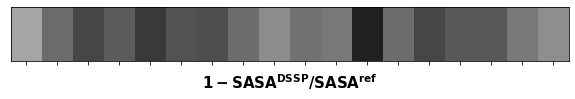

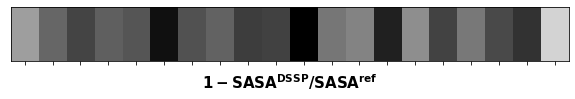

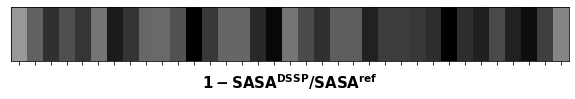

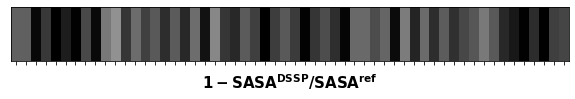

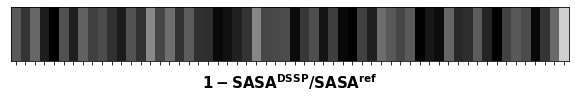

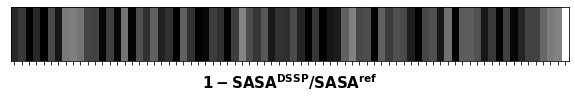

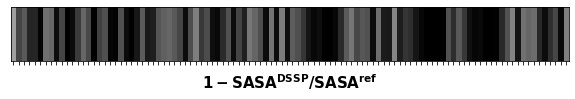

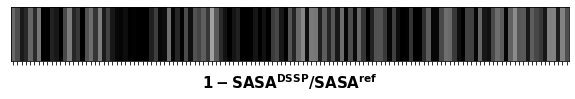

In [34]:
for nk, pkey in enumerate(SASAdict.keys()):
    sasa_fig = _fig_SASA_pdb(SASAdict[pkey], pkey, fnum=nk)
    sasa_fig.savefig('{}{}/{}_SASA_PDB_Heatmap_gray_fixedSize.png'.format(CorrFuncLoc2, pkey, pkey),
                     dpi=600, bbox_inches='tight')

In [ ]:
colspecs = [(0,6), (6,11), (11,13), (13,16), (16, 18), (19,26), (27,31), (31,35), (35,39)]
col_names = ['#','Residue','Chain','AA','SS','SS_Details', 'BP1','BP2','ACC']
SASASeries_GB3 = pd.read_fwf('{}/{}_dssp.dat'.format(CorrFuncLoc2, SASAList[3]), skiprows=28,
                         colspecs=colspecs, header=None, usecols=range(0,9), names=col_names)
SASASeries_GB3['SS'] = SASASeries_GB3['SS'].fillna('C')
SASASeries_UBQ = pd.read_fwf('{}/{}_dssp.dat'.format(CorrFuncLoc2, SASAList[5]), skiprows=28,
                         colspecs=colspecs, header=None, usecols=range(0,9), names=col_names)
SASASeries_UBQ['SS'] = SASASeries_UBQ['SS'].fillna('C')

In [ ]:
SASASeries_GB3[['Residue','SS','ACC']].to_csv('{}{}/Analysis/GB3_DSSP_SecondaryStructure_SASA.csv'.format(CorrFuncLoc2,'GB3'))
SASASeries_UBQ[['Residue','SS','ACC']].to_csv('{}{}/Analysis/UBQ_DSSP_SecondaryStructure_SASA.csv'.format(CorrFuncLoc2,'Ubiquitin'))

In [ ]:
colspecs = [(0,6), (6,11), (11,13), (13,16), (16, 18), (19,26), (27,31), (31,35), (35,39)]

In [ ]:
SASASeries['SS'] = SASASeries['SS'].fillna('C')

In [ ]:
SASASeries